In [8]:
import os
import json
import matplotlib.pyplot as plt

import xarray as xr
import seaborn as sns
import pandas as pd
import numpy as np

import scipy as sp

In [9]:
from pypalettes import load_cmap
cmap = load_cmap("highcontrast")

In [10]:
# Reanalysis data
obs = pd.read_csv('/home/links/ct715/eddy_feedback/chapter1/reanalysis/data/1979-2016/jra55_efp_k123_1979-2016.csv')

# Much cleaner - use a nested dictionary
obs_values = {}

for time_freq in ['6h', 'daily']:
    obs_values[time_freq] = {}
    for div1_method in ['div1_QG', 'div1_QG_123', 'div1_QG_gt3']:
        result = obs.query(f"time_freq == '{time_freq}' and div1_method == '{div1_method}'")
        obs_values[time_freq][div1_method] = {
            'nh': result['efp_nh_500'].values[0],
            'sh': result['efp_sh_500'].values[0]
        }

# # Access like:
# obs_values['6h']['div1_QG']['nh'] 
# obs_values['daily']['div1_QG_123']['sh'] 


# PAMIP Daily EFP

In [11]:
df = pd.read_csv('/home/links/ct715/eddy_feedback/chapter1/pamip/data/pamip_daily8_efp_k123_winters.csv')
df

,model,efp_nh,efp_nh_gt3,efp_nh_123,efp_sh,efp_sh_gt3,efp_sh_123
0,AWI-CM-1-1-MR,0.2592,0.1931,0.0607,0.2557,0.2325,0.0223
1,CNRM-CM6-1,0.2244,0.1286,0.0827,0.1944,0.1805,0.0132
2,CanESM5,0.3133,0.1771,0.1232,0.3271,0.2758,0.0195
3,FGOALS-f3-L,0.2353,0.1231,0.0731,0.1273,0.1061,0.0114
4,HadGEM3-GC31-LL,0.1735,0.1072,0.0529,0.1729,0.1528,0.0160
5,HadGEM3-GC31-MM,0.2525,0.1087,0.1022,0.1874,0.1544,0.0140
6,IPSL-CM6A-LR,0.2623,0.1947,0.0654,0.2015,0.1938,0.0179
7,MIROC6,0.1592,0.1045,0.0425,0.2058,0.1458,0.0273


Plot saved to /home/links/ct715/eddy_feedback/chapter1/cmip6/historical_runs/analysis_historical/plots/NHvsSH_PAMIP-daily8_all-k_hist.png


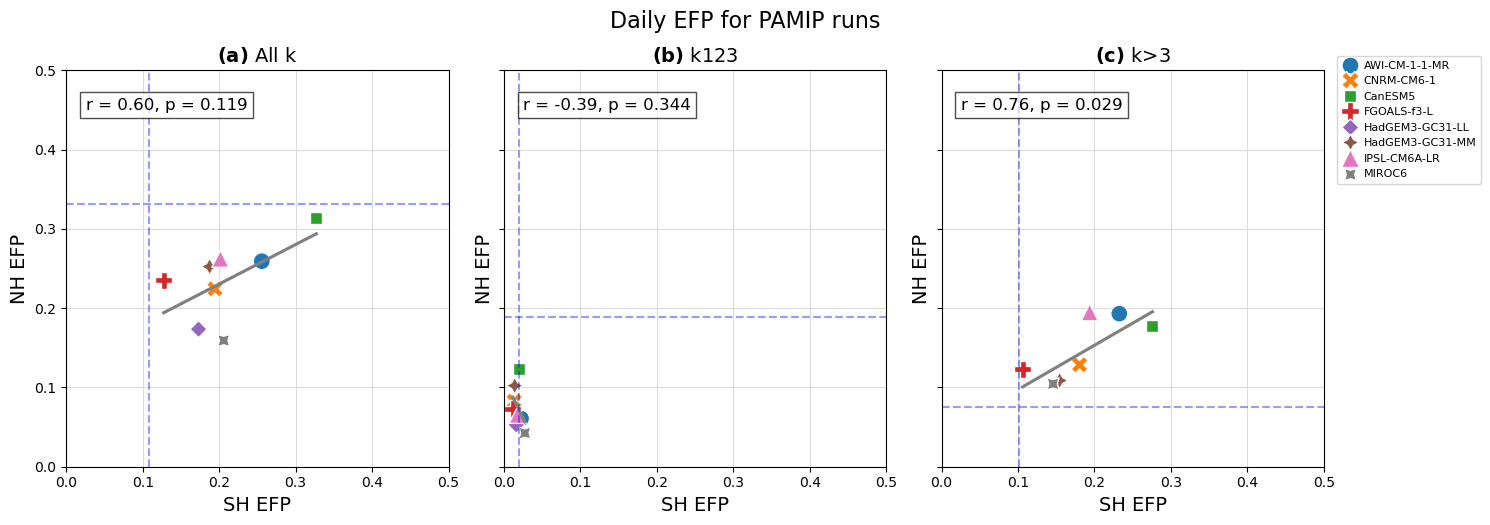

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Panel (a)
sns.regplot(ax=axes[0], data=df, x='efp_sh', y='efp_nh',
            scatter_kws={'color': 'white'}, line_kws={"color": "gray"}, ci=None)

sns.scatterplot(ax=axes[0], data=df, x='efp_sh', y='efp_nh',
                hue='model', style='model', s=150)

axes[0].axhline(y=obs_values['daily']['div1_QG']['nh'], color='blue', linestyle='--', alpha=0.4)
axes[0].axvline(x=obs_values['daily']['div1_QG']['sh'], color='blue', linestyle='--', alpha=0.4)


r, p = sp.stats.pearsonr(x=df['efp_nh'], y=df['efp_sh'])
axes[0].text(0.05, 0.9, f"r = {r:.2f}, p = {p:.3f}", transform=axes[0].transAxes,
             bbox=dict(facecolor="white", alpha=0.7), fontsize=12)

axes[0].set_xlabel('SH EFP', fontsize=14)
axes[0].set_ylabel('NH EFP', fontsize=14)
axes[0].set_xlim(0, 0.5)
axes[0].set_ylim(0, 0.5)
axes[0].set_title('$\\bf{(a)}$ All k', fontsize=14)
axes[0].legend_.remove()
axes[0].grid(visible=True, color='gainsboro')
axes[0].set_axisbelow(True)


# Panel (b)
sns.regplot(ax=axes[1], data=df, x='efp_sh_123', y='efp_nh_123',
            scatter_kws={'color': 'white'}, line_kws={"color": "gray"}, ci=None)

sns.scatterplot(ax=axes[1], data=df, x='efp_sh_123', y='efp_nh_123',
                hue='model', style='model', s=150)

axes[1].axhline(y=obs_values['daily']['div1_QG_123']['nh'], color='blue', linestyle='--', alpha=0.4)
axes[1].axvline(x=obs_values['daily']['div1_QG_123']['sh'], color='blue', linestyle='--', alpha=0.4)


r, p = sp.stats.pearsonr(x=df['efp_nh_123'], y=df['efp_sh_123'])
axes[1].text(0.05, 0.9, f"r = {r:.2f}, p = {p:.3f}", transform=axes[1].transAxes,
             bbox=dict(facecolor="white", alpha=0.7), fontsize=12)

axes[1].set_xlabel('SH EFP', fontsize=14)
axes[1].set_ylabel('NH EFP', fontsize=14)
axes[1].set_xlim(0, 0.5)
axes[1].set_ylim(0, 0.5)
axes[1].set_title('$\\bf{(b)}$ k123', fontsize=14)
axes[1].legend_.remove()
axes[1].grid(visible=True, color='gainsboro')
axes[1].set_axisbelow(True)


# Panel (c)
sns.regplot(ax=axes[2], data=df, x='efp_sh_gt3', y='efp_nh_gt3',
            scatter_kws={'color': 'white'}, line_kws={"color": "gray"}, ci=None)

sns.scatterplot(ax=axes[2], data=df, x='efp_sh_gt3', y='efp_nh_gt3',
                hue='model', style='model', s=150)

axes[2].axhline(y=obs_values['daily']['div1_QG_gt3']['nh'], color='blue', linestyle='--', alpha=0.4)
axes[2].axvline(x=obs_values['daily']['div1_QG_gt3']['sh'], color='blue', linestyle='--', alpha=0.4)


r, p = sp.stats.pearsonr(x=df['efp_nh_gt3'], y=df['efp_sh_gt3'])
axes[2].text(0.05, 0.9, f"r = {r:.2f}, p = {p:.3f}", transform=axes[2].transAxes,
             bbox=dict(facecolor="white", alpha=0.7), fontsize=12)

axes[2].set_xlabel('SH EFP', fontsize=14)
axes[2].set_ylabel('NH EFP', fontsize=14)
axes[2].set_xlim(0, 0.5)
axes[2].set_ylim(0, 0.5)
axes[2].set_title('$\\bf{(c)}$ k>3', fontsize=14)
axes[2].legend_.remove()
axes[2].grid(visible=True, color='gainsboro')
axes[2].set_axisbelow(True)


# Move legend outside the left panel now
axes[2].legend(
    bbox_to_anchor=(1.02, 1.05),
    loc='upper left',
    prop={'size': 8},  # Adjust the font size
    handlelength=1.5,  # Adjust the length of the legend handles
    handletextpad=0.5   # Adjust the padding between the handle and text
)#, title='model')

plt.tight_layout()
plt.suptitle('Daily EFP for PAMIP runs', fontsize=16, y=1.04)



# Ask the user if they want to save the file
save_path = '/home/links/ct715/eddy_feedback/chapter1/cmip6/historical_runs/analysis_historical/plots'
filename = 'NHvsSH_PAMIP-daily8_all-k_hist.png'
full_path = os.path.join(save_path, filename)

user_input = input(f"Do you want to save the plot to {full_path}? (y/n): ").strip().lower()

if user_input == 'y':
    plt.savefig(full_path, bbox_inches='tight')
    print(f"Plot saved to {full_path}")
else:
    print("Plot not saved.")
    
    
    
plt.show()